## Task 4

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # prevents OpenMP from crashing when multiple libs are loaded 

import sys
import pickle
import numpy as np
from pathlib import Path
from PIL import Image
import time
from collections import Counter
from collections import defaultdict

# Add repo root to path
REPO_ROOT = Path(".").resolve().parent
sys.path.append(str(REPO_ROOT))

# Anchor everything to wherever this notebook is sitting
BASE_DIR = REPO_ROOT
DATA_DIR = BASE_DIR / "multi_image_identities"
GALLERY_DIR = DATA_DIR / "multi_image_gallery" # reference images we search against
PROBE_DIR = DATA_DIR / "probe" # query images we're trying to identify

print("Setup complete!")

Setup complete!


In [2]:
# First let's see how many images each identity has
# Distribution varies from 1 to 10
images_per_identity = {}

for identity_dir in sorted(GALLERY_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    identity = identity_dir.name
    n_images = len(list(identity_dir.glob("*.jpg")))
    images_per_identity[identity] = n_images

# Group identities by how many images they have (e.g. {1: 629, 2: 118, ...})
distribution = Counter(images_per_identity.values())

print("GALLERY IMAGE DISTRIBUTION")
print(f"{'Images per ID':<15} {'Count':<10}")

for n_imgs in sorted(distribution.keys()):
    count = distribution[n_imgs]
    print(f"{n_imgs:<15} {count:<10}")

print(f"\nTotal identities: {len(images_per_identity)}")
print(f"Max images per identity: {max(images_per_identity.values())}")
print(f"Min images per identity: {min(images_per_identity.values())}")

GALLERY IMAGE DISTRIBUTION
Images per ID   Count     
1               629       
2               118       
3               84        
4               46        
5               26        
6               19        
7               11        
8               11        
9               5         
10              51        

Total identities: 1000
Max images per identity: 10
Min images per identity: 1


In [3]:
from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce

pre = Preprocessing(image_size=224)
model_vgg = Embedding(pretrained="vggface2", device=pre.device)
model_casia = Embedding(pretrained="casia-webface", device=pre.device)

# Build gallery embeddings for both models in a single pass (saves reading each image twice)
print("Building gallery embeddings...")

gallery_data_vgg = defaultdict(list) # identity -> [emb1, emb2, ...]
gallery_data_casia = defaultdict(list)

for identity_dir in sorted(GALLERY_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    identity = identity_dir.name
    
    for img_path in sorted(identity_dir.glob("*.jpg")):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        
        # Encode with both models while the tensor is already in memory
        emb_vgg = model_vgg.encode(tensor).astype(np.float32)
        emb_casia = model_casia.encode(tensor).astype(np.float32)
        
        gallery_data_vgg[identity].append(emb_vgg)
        gallery_data_casia[identity].append(emb_casia)

print(f"Built embeddings for {len(gallery_data_vgg)} identities.")

# Build probe embeddings
# Probe set has one image per identity -> store as a dict
print("Building probe embeddings...")
probe_data_vgg = {}
probe_data_casia = {}

for identity_dir in sorted(PROBE_DIR.iterdir()):
    if not identity_dir.is_dir():
        continue
    identity = identity_dir.name
    
    for img_path in identity_dir.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        tensor = pre.process(img)
        
        probe_data_vgg[identity] = model_vgg.encode(tensor).astype(np.float32)
        probe_data_casia[identity] = model_casia.encode(tensor).astype(np.float32)

print(f"Built probe embeddings for {len(probe_data_vgg)} identities.")

/Users/radinabakalov/ironclad-radinabakalov/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Building gallery embeddings...
Built embeddings for 1000 identities.
Building probe embeddings...
Built probe embeddings for 999 identities.


In [4]:
# Filter to only identities that have the full 10 images in the gallery
# This ensures every m value (1 through 10) is testable on the same set of identities
max_images = 10
full_identities = [id for id, count in images_per_identity.items() if count == max_images]

print(f"Using {len(full_identities)} identities with {max_images} images each.")
print("This ensures a fair comparison across all m values!")

Using 51 identities with 10 images each.
This ensures a fair comparison across all m values!


In [5]:
def evaluate_with_m_images(gallery_data, probe_data, identities, m, k=5):
    """
    Build a gallery with exactly m images per identity and evaluate.
    """
    gallery_embs = []
    gallery_labels = []
    
    # Use only the first m embeddings per identity (simulates having m reference images)
    for identity in identities:
        embs = gallery_data[identity][:m]
        for emb in embs:
            gallery_embs.append(emb)
            gallery_labels.append(identity)
    
    # Stack and build a fresh index for this value of m
    gallery_embs = np.vstack(gallery_embs)
    dim = gallery_embs.shape[1]
    index = FaissBruteForce(dim=dim, metric="cosine")
    index.add_embeddings(gallery_embs, gallery_labels)
    
    # Evaluate
    correct_top1 = 0
    correct_top5 = 0
    total = 0
    
    for identity in identities:
        # Skip any identities that don't have a probe image
        if identity not in probe_data:
            continue
        
        # Reshape to 2D and normalize for cosine similarity
        query = probe_data[identity].reshape(1, -1).astype(np.float32)
        query = query / np.linalg.norm(query)
        
        distances, indices = index.index.search(query, k)
        top_labels = [gallery_labels[int(idx)] for idx in indices[0]]
        
        if top_labels[0] == identity:
            correct_top1 += 1
        if identity in top_labels:
            correct_top5 += 1
        total += 1
    
    return correct_top1 / total, correct_top5 / total

In [6]:
# m from 1 to 10 
# Testing how much accuracy improves as we add more gallery images per person
m_values = list(range(1, 11))

vgg_results = []
casia_results = []

print("Evaluating VGG across m values...")
for m in m_values:
    top1, top5 = evaluate_with_m_images(gallery_data_vgg, probe_data_vgg, full_identities, m)
    vgg_results.append({"m": m, "top1": top1, "top5": top5})
    print(f"m={m:2d}: Top-1={top1:.4f}, Top-5={top5:.4f}")

# Run the same sweep for CASIA so we can compare the two models side by side
print("\nEvaluating CASIA across m values...")
for m in m_values:
    top1, top5 = evaluate_with_m_images(gallery_data_casia, probe_data_casia, full_identities, m)
    casia_results.append({"m": m, "top1": top1, "top5": top5})
    print(f"m={m:2d}: Top-1 = {top1:.4f}, Top-5 = {top5:.4f}")

Evaluating VGG across m values...
m= 1: Top-1=0.8824, Top-5=1.0000
m= 2: Top-1=0.9412, Top-5=1.0000
m= 3: Top-1=0.9412, Top-5=1.0000
m= 4: Top-1=0.9608, Top-5=0.9804
m= 5: Top-1=0.9804, Top-5=0.9804
m= 6: Top-1=0.9804, Top-5=0.9804
m= 7: Top-1=0.9804, Top-5=0.9804
m= 8: Top-1=0.9804, Top-5=0.9804
m= 9: Top-1=0.9804, Top-5=1.0000
m=10: Top-1=0.9804, Top-5=1.0000

Evaluating CASIA across m values...
m= 1: Top-1 = 0.5098, Top-5 = 0.6863
m= 2: Top-1 = 0.6471, Top-5 = 0.8235
m= 3: Top-1 = 0.7059, Top-5 = 0.9216
m= 4: Top-1 = 0.7255, Top-5 = 0.9216
m= 5: Top-1 = 0.7843, Top-5 = 0.9412
m= 6: Top-1 = 0.8431, Top-5 = 0.9216
m= 7: Top-1 = 0.8431, Top-5 = 0.9020
m= 8: Top-1 = 0.8627, Top-5 = 0.9216
m= 9: Top-1 = 0.9020, Top-5 = 0.9608
m=10: Top-1 = 0.9020, Top-5 = 0.9412


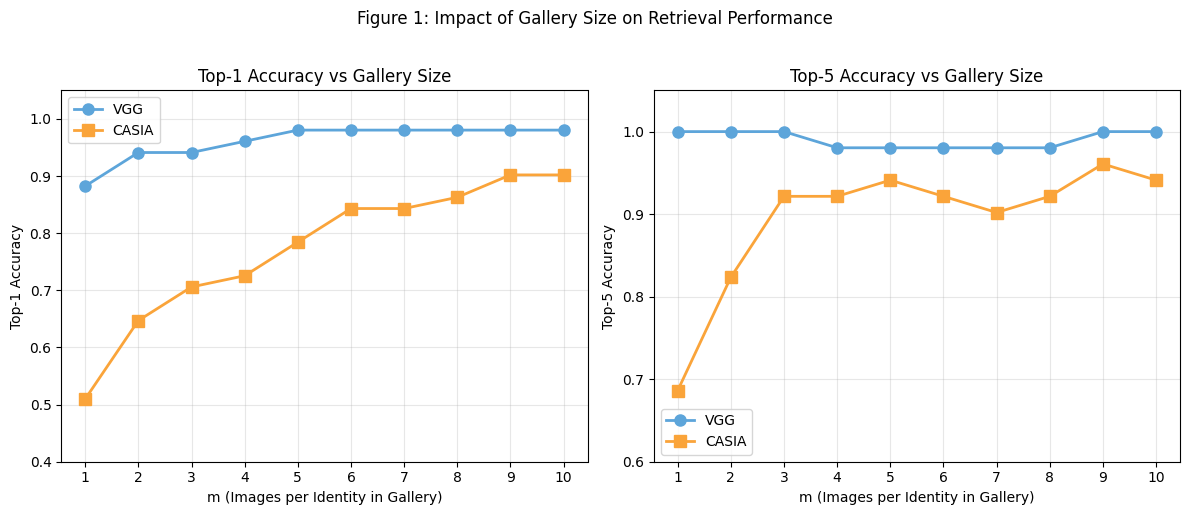

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/gallery_size_impact.png


In [7]:
import matplotlib.pyplot as plt

figures_dir = BASE_DIR / "analysis" / "figures"

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pull accuracy values out of the results dicts for plotting
vgg_top1 = [r["top1"] for r in vgg_results]
vgg_top5 = [r["top5"] for r in vgg_results]
casia_top1 = [r["top1"] for r in casia_results]
casia_top5 = [r["top5"] for r in casia_results]

# Left plot: Top-1 accuracy as gallery size grows
ax1 = axes[0]
ax1.plot(m_values, vgg_top1, 'o-', label='VGG', color='#5DA5DA', linewidth=2, markersize=8)
ax1.plot(m_values, casia_top1, 's-', label='CASIA', color='#FAA43A', linewidth=2, markersize=8)
ax1.set_xlabel('m (Images per Identity in Gallery)')
ax1.set_ylabel('Top-1 Accuracy')
ax1.set_title('Top-1 Accuracy vs Gallery Size')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.05) # CASIA starts lower, so give it room at the bottom
ax1.set_xticks(m_values) # one tick per m value so the x-axis is easy to see

# Right plot: Top-5 accuracy as gallery size grows
ax2 = axes[1]
ax2.plot(m_values, vgg_top5, 'o-', label='VGG', color='#5DA5DA', linewidth=2, markersize=8)
ax2.plot(m_values, casia_top5, 's-', label='CASIA', color='#FAA43A', linewidth=2, markersize=8)
ax2.set_xlabel('m (Images per Identity in Gallery)')
ax2.set_ylabel('Top-5 Accuracy')
ax2.set_title('Top-5 Accuracy vs Gallery Size')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.6, 1.05) # Top-5 starts higher
ax2.set_xticks(m_values)

plt.suptitle('Figure 1: Impact of Gallery Size on Retrieval Performance', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / "gallery_size_impact.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'gallery_size_impact.png'}")

In [8]:
print("GALLERY SIZE IMPACT (m = images per identity)")
print(f"{'m':<4} {'VGG Top-1':>12} {'VGG Top-5':>12} {'CASIA Top-1':>12} {'CASIA Top-5':>12}")

for i, m in enumerate(m_values):
    print(f"{m:<4} {vgg_results[i]['top1']:>12.4f} {vgg_results[i]['top5']:>12.4f} {casia_results[i]['top1']:>12.4f} {casia_results[i]['top5']:>12.4f}")

GALLERY SIZE IMPACT (m = images per identity)
m       VGG Top-1    VGG Top-5  CASIA Top-1  CASIA Top-5
1          0.8824       1.0000       0.5098       0.6863
2          0.9412       1.0000       0.6471       0.8235
3          0.9412       1.0000       0.7059       0.9216
4          0.9608       0.9804       0.7255       0.9216
5          0.9804       0.9804       0.7843       0.9412
6          0.9804       0.9804       0.8431       0.9216
7          0.9804       0.9804       0.8431       0.9020
8          0.9804       0.9804       0.8627       0.9216
9          0.9804       1.0000       0.9020       0.9608
10         0.9804       1.0000       0.9020       0.9412


In [9]:
task4_results = {
    "m_values": m_values,
    "vgg": vgg_results,
    "casia": casia_results,
    "n_identities_tested": len(full_identities),
    "experiment_note": "Used 51 identities with exactly 10 images for fair comparison"
}

results_path = BASE_DIR / "analysis" / "task4_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(task4_results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task4_results.pkl
